# Module 02: Random Variables & Distributions

> **Durrett Ch. 1.2–1.3 — Distributions & Random Variables**

A **random variable** X is a function X: Ω → ℝ that maps outcomes to real numbers.

| Symbol | Meaning |
|---|---|
| Ω | sample space — all possible outcomes (e.g. {H, T} for a coin flip) |
| ω | one outcome, an element of Ω (e.g. ω = H) |
| ℝ | the real numbers |
| F | the σ-algebra on Ω — the events we're allowed to assign probabilities to |
| B | a Borel set — a "nice" subset of ℝ (intervals, and anything built from them) |

X is called **measurable** if for every Borel set B, the preimage

```
X⁻¹(B) = {ω ∈ Ω : X(ω) ∈ B}
```
is itself an event in F. This preimage operation *pulls back* sets from ℝ into Ω, which is what lets us reuse the existing probability measure P on Ω to answer questions about X.

## Induced distribution

Every random variable X **pushes forward** P into a probability measure μ on ℝ:

```
μ(B) = P(X ∈ B) = P(X⁻¹(B))
```

μ is called the **distribution** of X.

---

## Cumulative Distribution Function (CDF)

The cumulative distribution function(CDF) is a function that describes the probability that a random variable takes on a value less than or equal to a specific number.

The **CDF** of X is: F(x) = P(X ≤ x) = P({ω : X(ω) ≤ x})

Properties (these characterise valid CDFs):
1. **Non-decreasing**: x ≤ y ⟹ F(x) ≤ F(y)
2. **Right-continuous**: lim_{y↓x} F(y) = F(x)
3. **Limits**: F(-∞) = 0, F(+∞) = 1

**the CDF completely determines the distribution of X.**

---

## Probability Density Function (PDF)

It's a function that describes the likelihood of a continuous random variable taking on a particular value, where the probability of the variable falling a specific range is given by the area under the curve of the PDF over that range.


If X has CDF F that is absolutely continuous, then there exists a function f(x) ≥ 0 such that:
```
F(x) = ∫_{-∞}^{x} f(t) dt
```

f is called the **probability density function (PDF)** of X. Note:
- f(x) is NOT a probability — it's a density: P(x ≤ X ≤ x+ε) ≈ f(x)·ε
- ∫_{-∞}^{+∞} f(x) dx = 1
- P(X ∈ [a, b]) = ∫_a^b f(x) dx


---

## Key Distributions

### Uniform U(a, b)
- PDF: f(x) = 1/(b-a) for x ∈ [a, b], else 0
- CDF: F(x) = (x-a)/(b-a) for x ∈ [a, b]
- **LLM use**: Random initialization, dropout mask, data shuffling

### Normal N(μ, σ²)
- PDF: f(x) = (1/√(2πσ²)) exp(-(x-μ)²/(2σ²))
- CDF: F(x) = Φ((x-μ)/σ) where Φ is the standard normal CDF
- **LLM use**: Weight initialization (He/Xavier), gradient noise in SGD, Gaussian prior in VAEs

### Bernoulli Ber(p)
- P(X=1) = p, P(X=0) = 1-p
- **LLM use**: Dropout (each neuron dropped with prob p), binary classification heads

### Categorical (Multinomial with n=1)
- P(X=k) = pₖ, Σpₖ = 1
- **LLM use**: Next-token distribution; the softmax output IS the parameter vector p

### Exponential Exp(λ)
- PDF: f(x) = λ e^{-λx} for x ≥ 0
- CDF: F(x) = 1 - e^{-λx}
- **LLM use**: Modeling inter-arrival times, token generation latency

---

## Discrete vs Continuous Random Variables

| Property | Discrete | Continuous |
|----------|----------|------------|
| Distribution | PMF p(xᵢ) | PDF f(x) |
| Probabilities | P(X=x) = p(x) > 0 possible | P(X=x) = 0 always |
| CDF | Step function | Absolutely continuous |
| Sum/Integral | Σ p(xᵢ) = 1 | ∫ f(x)dx = 1 |
| Example | Next token ID | Attention score |

---

## Measurability — Why It Matters

Not all functions Ω → ℝ are random variables. Consider an **unmeasurable** set (Vitali set) S ⊂ [0,1]. The indicator function 1_S(ω) = 1 if ω ∈ S, 0 otherwise, is NOT measurable on ([0,1], Borel sets, Lebesgue measure) — its probability is undefined.

**Practical meaning**: In LLMs, every quantity we compute (logits, attention scores, loss) must be a measurable function of the random input (data batch). This is guaranteed by continuity of neural network operations.

---

## Connection to Modern LLM Techniques

| Random Variable Concept | LLM Application |
|------------------------|-----------------|
| X: Ω → ℝ (measurable function) | Any computed quantity (loss, logit, attention score) |
| CDF F(x) | Sampling threshold for top-p (nucleus) sampling |
| PDF f(x) | Probability density of continuous latent codes (VAE) |
| Bernoulli Ber(p) | Dropout mask, binary reward in RLHF |
| Normal N(0, σ²) | Weight init (He: σ² = 2/fan_in), gradient noise |
| Categorical | Softmax output = next-token distribution |
| Joint distribution P(X₁,...,Xₙ) | Joint probability of a full generated sequence |

**Top-p (nucleus) sampling**: Given sorted probabilities p₁ ≥ p₂ ≥ ..., find smallest k such that Σᵢ₌₁ᵏ pᵢ ≥ p. This is literally finding where the CDF hits threshold p, then sampling uniformly from the top-k set. The CDF makes this precise.

**RLHF reward modeling**: The reward R(x, y) is a random variable (function of the random batch). Its distribution drives the DPO objective:
```
π*(y|x) ∝ π_ref(y|x) · exp(R(x,y)/β)
```
This is the Gibbs distribution — a well-defined probability measure derived from R.

---

## Reference
- Durrett §1.2 (Distributions)
- Durrett §1.3 (Random Variables)

=== Verifying PDF ===
f(x) = 6(1/4 - (x - 1/2)²) for x ∈ [0,1]
min(f) = 0.0000  (must be ≥ 0)
max(f) = 1.5000  (at x=0.5, should be 6×(1/4)=1.5)
∫₀¹ f(x) dx = 1.000000  (must be 1.0, error=1.11e-14)
F(0) = 0.0000  (must be 0)
F(1) = 1.0000  (must be 1)
F(0.5) = 0.5000  (by symmetry should be 0.5)

CDF verification at x=0.25,0.5,0.75:
  Numeric:     [0.15625 0.5     0.84375]
  Closed-form: [0.15625 0.5     0.84375]

=== Key Distributions in LLMs ===
Uniform(0,1): mean=0.4942 (theory: 0.5), var=0.0827 (theory: 0.0833)
He init N(0, √(2/768)): mean=0.00063, std=0.05102 (theory: 0.05103)
Standard Normal N(0,1): P(|Z|≤1) = 0.6825 (theory: 0.6827)
                        P(|Z|≤2) = 0.9584 (theory: 0.9545)
                        P(|Z|≤3) = 0.9979 (theory: 0.9973)
Dropout mask Bernoulli(0.9): keep_rate=0.8970 (theory: 0.9)
Categorical (V=100): H(P)=4.18 bits (max possible: 4.61)

=== CDF Properties ===
CDF non-decreasing: True
F(-∞) ≈ F(-4) = 0.000032  (→ 0)
F(+∞) ≈ F(+4) = 0.999968  (→ 1)
Rig

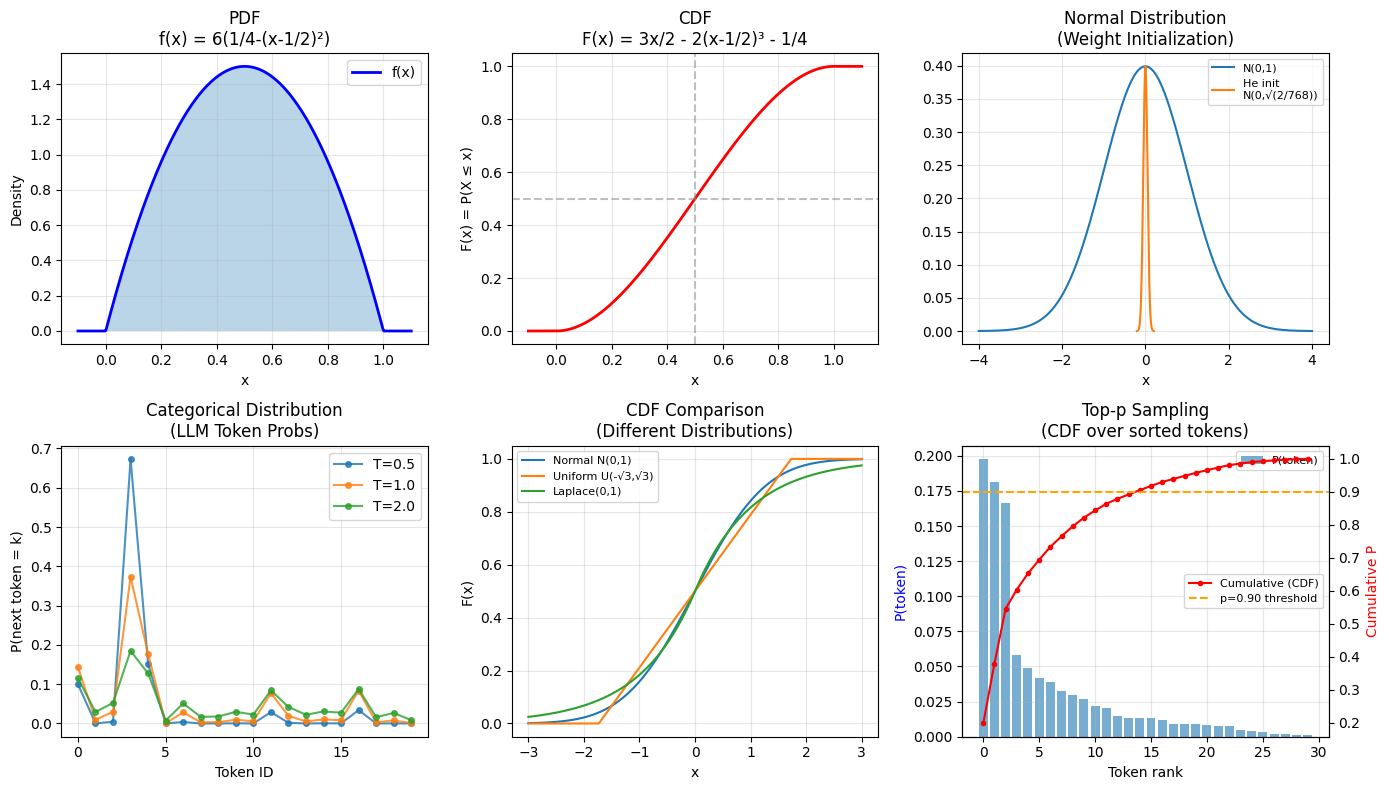


[Plot saved: random_variables_demo.png]

KEY TAKEAWAYS

1. A random variable X maps outcomes Ω → ℝ (must be measurable).
2. CDF F(x) = P(X ≤ x) fully characterizes the distribution.
3. PDF f(x) exists if CDF is absolutely continuous: F(x) = ∫f(t)dt.
4. PDF f(x) = 6(1/4-(x-1/2)²) is valid: ≥0 and ∫=1.
5. CDF closed form: F(x) = 3x/2 - 2(x-1/2)³ - 1/4.
6. Top-p sampling = find where the sorted-token CDF hits threshold p.
7. He initialization: σ = √(2/fan_in) from variance analysis of ReLU.



In [1]:
"""
Module 02: Random Variables & Distributions — Demo Code
=======================================================
Concepts: CDF, PDF, common distributions, measurability.
Connection: LLM sampling strategies, weight initialization, RLHF.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad


# ─────────────────────────────────────────────────────────────
# 1. Verifying the PDF is Valid
# ─────────────────────────────────────────────────────────────

def pdf(x):
    """f(x) = 6(1/4 - (x - 1/2)²) for x ∈ [0,1], else 0."""
    if np.isscalar(x):
        return 6 * (0.25 - (x - 0.5)**2) if 0 <= x <= 1 else 0.0
    x = np.asarray(x, dtype=float)
    result = 6 * (0.25 - (x - 0.5)**2)
    result[x < 0] = 0.0
    result[x > 1] = 0.0
    return result


def cdf(x):
    """F(x) = 3x/2 - 2(x-1/2)³ - 1/4  for x ∈ [0,1]."""
    if np.isscalar(x):
        if x < 0:
            return 0.0
        if x > 1:
            return 1.0
        return 1.5 * x - 2 * (x - 0.5)**3 - 0.25
    x = np.asarray(x, dtype=float)
    result = 1.5 * x - 2 * (x - 0.5)**3 - 0.25
    result[x < 0] = 0.0
    result[x > 1] = 1.0
    return result


def verify_pdf():
    print("=== Verifying PDF ===")
    print("f(x) = 6(1/4 - (x - 1/2)²) for x ∈ [0,1]")

    # 1. Non-negative?
    xs = np.linspace(0, 1, 1000)
    vals = pdf(xs)
    print(f"min(f) = {vals.min():.4f}  (must be ≥ 0)")
    print(f"max(f) = {vals.max():.4f}  (at x=0.5, should be 6×(1/4)=1.5)")

    # 2. Integrates to 1?
    integral, err = quad(pdf, 0, 1)
    print(f"∫₀¹ f(x) dx = {integral:.6f}  (must be 1.0, error={err:.2e})")

    # 3. CDF boundary conditions
    print(f"F(0) = {cdf(0):.4f}  (must be 0)")
    print(f"F(1) = {cdf(1):.4f}  (must be 1)")
    print(f"F(0.5) = {cdf(0.5):.4f}  (by symmetry should be 0.5)")

    # Verify CDF matches numerical integration of PDF
    cdf_numeric = np.array([quad(pdf, 0, x)[0] for x in [0.25, 0.5, 0.75]])
    cdf_closed = np.array([cdf(x) for x in [0.25, 0.5, 0.75]])
    print(f"\nCDF verification at x=0.25,0.5,0.75:")
    print(f"  Numeric:     {cdf_numeric}")
    print(f"  Closed-form: {cdf_closed}")


verify_pdf()


# ─────────────────────────────────────────────────────────────
# 2. Key Distributions Used in LLMs
# ─────────────────────────────────────────────────────────────

def distributions_overview():
    print("\n=== Key Distributions in LLMs ===")
    np.random.seed(42)

    # Uniform
    u = np.random.uniform(0, 1, 10000)
    print(f"Uniform(0,1): mean={u.mean():.4f} (theory: 0.5), var={u.var():.4f} (theory: 0.0833)")

    # Normal (weight initialization)
    fan_in = 768  # transformer hidden dim
    sigma_he = np.sqrt(2 / fan_in)
    w = np.random.normal(0, sigma_he, 10000)
    print(f"He init N(0, √(2/768)): mean={w.mean():.5f}, std={w.std():.5f} (theory: {sigma_he:.5f})")

    # Normal (standard)
    z = np.random.randn(10000)
    print(f"Standard Normal N(0,1): P(|Z|≤1) = {np.mean(np.abs(z)<=1):.4f} (theory: 0.6827)")
    print(f"                        P(|Z|≤2) = {np.mean(np.abs(z)<=2):.4f} (theory: 0.9545)")
    print(f"                        P(|Z|≤3) = {np.mean(np.abs(z)<=3):.4f} (theory: 0.9973)")

    # Bernoulli (dropout)
    p_drop = 0.1
    mask = np.random.binomial(1, 1 - p_drop, 10000)
    print(f"Dropout mask Bernoulli(0.9): keep_rate={mask.mean():.4f} (theory: 0.9)")

    # Categorical (next token)
    vocab_size = 100
    logits = np.random.randn(vocab_size)
    probs = np.exp(logits - logits.max())
    probs /= probs.sum()
    tokens = np.random.choice(vocab_size, size=1000, p=probs)
    entropy = -np.sum(probs * np.log(probs + 1e-12))
    print(f"Categorical (V={vocab_size}): H(P)={entropy:.2f} bits (max possible: {np.log(vocab_size):.2f})")


distributions_overview()


# ─────────────────────────────────────────────────────────────
# 3. CDF — The Unifying Concept
# ─────────────────────────────────────────────────────────────

def cdf_properties_demo():
    print("\n=== CDF Properties ===")
    from scipy.stats import norm

    # Verify three CDF properties for N(0,1)
    xs = np.linspace(-4, 4, 1000)
    F = norm.cdf(xs)

    # Non-decreasing
    print(f"CDF non-decreasing: {np.all(np.diff(F) >= 0)}")
    # Limits
    print(f"F(-∞) ≈ F(-4) = {norm.cdf(-4):.6f}  (→ 0)")
    print(f"F(+∞) ≈ F(+4) = {norm.cdf(4):.6f}  (→ 1)")

    # Right continuity (verified by definition of limit)
    x = 1.0
    eps_vals = [0.1, 0.01, 0.001, 0.0001]
    print(f"Right continuity at x=1.0: F(1+ε) → F(1) = {norm.cdf(1):.6f}")
    for eps in eps_vals:
        print(f"  F(1+{eps}) = {norm.cdf(1 + eps):.6f}")


cdf_properties_demo()


# ─────────────────────────────────────────────────────────────
# 4. Top-p (Nucleus) Sampling — CDF in Action
# ─────────────────────────────────────────────────────────────

def nucleus_sampling(logits: np.ndarray, p: float, temperature: float = 1.0):
    """
    Top-p sampling: sample from the smallest set of tokens
    whose cumulative probability exceeds p.

    This is exactly: find where the CDF (over sorted tokens) hits p.
    """
    probs = np.exp((logits - logits.max()) / temperature)
    probs /= probs.sum()

    sorted_idx = np.argsort(probs)[::-1]
    sorted_probs = probs[sorted_idx]

    cumulative_probs = np.cumsum(sorted_probs)
    # Find cutoff: first k where cumulative ≥ p
    cutoff_idx = np.searchsorted(cumulative_probs, p)
    nucleus_tokens = sorted_idx[:cutoff_idx + 1]
    nucleus_probs = sorted_probs[:cutoff_idx + 1]
    nucleus_probs /= nucleus_probs.sum()  # renormalize

    return np.random.choice(nucleus_tokens, p=nucleus_probs)


def top_p_demo():
    print("\n=== Top-p (Nucleus) Sampling — CDF Application ===")
    np.random.seed(42)
    vocab_size = 50000
    logits = np.random.randn(vocab_size) * 2  # typical LLM logit range

    probs = np.exp(logits - logits.max())
    probs /= probs.sum()

    for p in [0.5, 0.9, 0.95, 0.99, 1.0]:
        sorted_probs = np.sort(probs)[::-1]
        cumulative = np.cumsum(sorted_probs)
        k = np.searchsorted(cumulative, p) + 1
        print(f"  Top-p={p:.2f}: nucleus size = {k:5d} tokens out of {vocab_size} ({100*k/vocab_size:.2f}%)")

    print("\nTop-p uses the inverse CDF of the sorted token distribution.")
    print("Small p = sharp distribution (few tokens dominate).")
    print("Large p = flat distribution (many tokens in nucleus).")


top_p_demo()


# ─────────────────────────────────────────────────────────────
# 5. Visualization
# ─────────────────────────────────────────────────────────────

def plot_distributions():
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    xs = np.linspace(-0.1, 1.1, 500)

    # PDF and CDF
    axes[0, 0].plot(xs, pdf(xs), 'b-', linewidth=2, label='f(x)')
    axes[0, 0].fill_between(np.linspace(0, 1, 200), pdf(np.linspace(0, 1, 200)), alpha=0.3)
    axes[0, 0].set_title('PDF\nf(x) = 6(1/4-(x-1/2)²)')
    axes[0, 0].set_xlabel('x')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(xs, cdf(xs), 'r-', linewidth=2)
    axes[0, 1].set_title('CDF\nF(x) = 3x/2 - 2(x-1/2)³ - 1/4')
    axes[0, 1].set_xlabel('x')
    axes[0, 1].set_ylabel('F(x) = P(X ≤ x)')
    axes[0, 1].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].axvline(0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3)

    # Normal distribution (weight init)
    xs_n = np.linspace(-4, 4, 500)
    for sigma, label in [(1.0, 'N(0,1)'), (0.051, 'He init\nN(0,√(2/768))')]:
        axes[0, 2].plot(xs_n * sigma, stats.norm.pdf(xs_n), label=label)
    axes[0, 2].set_title('Normal Distribution\n(Weight Initialization)')
    axes[0, 2].set_xlabel('x')
    axes[0, 2].legend(fontsize=8)
    axes[0, 2].grid(True, alpha=0.3)

    # Categorical (softmax output)
    np.random.seed(0)
    vocab_size = 20
    logits = np.random.randn(vocab_size) * 2
    for temp in [0.5, 1.0, 2.0]:
        probs = np.exp(logits / temp)
        probs /= probs.sum()
        axes[1, 0].plot(probs, 'o-', markersize=4, label=f'T={temp}', alpha=0.8)
    axes[1, 0].set_title('Categorical Distribution\n(LLM Token Probs)')
    axes[1, 0].set_xlabel('Token ID')
    axes[1, 0].set_ylabel('P(next token = k)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # CDF comparison
    xs_c = np.linspace(-3, 3, 500)
    distributions = [
        ('Normal N(0,1)', stats.norm(0, 1).cdf(xs_c)),
        ('Uniform U(-√3,√3)', stats.uniform(-np.sqrt(3), 2*np.sqrt(3)).cdf(xs_c)),
        ('Laplace(0,1)', stats.laplace(0, 1).cdf(xs_c)),
    ]
    for name, cdf_vals in distributions:
        axes[1, 1].plot(xs_c, cdf_vals, label=name)
    axes[1, 1].set_title('CDF Comparison\n(Different Distributions)')
    axes[1, 1].set_xlabel('x')
    axes[1, 1].set_ylabel('F(x)')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)

    # Top-p illustration
    np.random.seed(42)
    vocab_size = 30
    logits = np.random.randn(vocab_size) * 1.5
    probs = np.exp(logits - logits.max())
    probs /= probs.sum()
    sorted_probs = np.sort(probs)[::-1]
    cumulative = np.cumsum(sorted_probs)
    axes[1, 2].bar(range(vocab_size), sorted_probs, alpha=0.6, label='P(token)')
    ax2 = axes[1, 2].twinx()
    ax2.plot(range(vocab_size), cumulative, 'r-o', markersize=3, label='Cumulative (CDF)')
    ax2.axhline(0.9, color='orange', linestyle='--', label='p=0.90 threshold')
    axes[1, 2].set_title('Top-p Sampling\n(CDF over sorted tokens)')
    axes[1, 2].set_xlabel('Token rank')
    axes[1, 2].set_ylabel('P(token)', color='blue')
    ax2.set_ylabel('Cumulative P', color='red')
    axes[1, 2].legend(loc='upper right', fontsize=8)
    ax2.legend(loc='center right', fontsize=8)
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('random_variables_demo.png', dpi=150)
    plt.show()
    plt.close()
    print("\n[Plot saved: random_variables_demo.png]")


plot_distributions()

print("\n" + "="*60)
print("KEY TAKEAWAYS")
print("="*60)
print("""
1. A random variable X maps outcomes Ω → ℝ (must be measurable).
2. CDF F(x) = P(X ≤ x) fully characterizes the distribution.
3. PDF f(x) exists if CDF is absolutely continuous: F(x) = ∫f(t)dt.
4. PDF f(x) = 6(1/4-(x-1/2)²) is valid: ≥0 and ∫=1.
5. CDF closed form: F(x) = 3x/2 - 2(x-1/2)³ - 1/4.
6. Top-p sampling = find where the sorted-token CDF hits threshold p.
7. He initialization: σ = √(2/fan_in) from variance analysis of ReLU.
""")
